<a href="https://colab.research.google.com/github/abdulazizabid/Scratch-model/blob/main/Neural_Network_with_python(no_numpy%2Cno_pytorch).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
class neuron:
  def __init__(self,data,_op='',_children=(),label=''):
    self.data=data
    self.grad=0.0
    self._op=_op
    self.label=label
    self._prev=set(_children)
    self._backward=lambda :None

  def __add__ (self,other):
    other= other if isinstance(other,neuron) else neuron(other)
    res=neuron(self.data+other.data,'+',(self,other))

    def _backward():
      self.grad+=1.0*res.grad
      other.grad+=1.0*res.grad
    res._backward=_backward
    return res

  def __radd__(self,other):
    other=other if isinstance(other,neuron) else neuron(other)
    res=neuron(self.data+other.data,'+',(self,other))

    def _backward():
      self.grad+=1.0*res.grad
      other.grad+=1.0*res.grad
    res._backward=_backward
    return res

  def __sub__(self,other):
    other=other if isinstance(other,neuron) else neuron(other)
    res=neuron(self.data-other.data,'-',(self,other))

    def _backward():
      self.grad+=1.0*res.grad
      other.grad-=1.0*res.grad
    res._backward=_backward
    return res

  def __rsub__(self,other):
    other=other if isinstance(other,neuron) else neuron(other)
    res=neuron(other.data-self.data,'-',(self,other))

    def _backward():
      self.grad+=1.0*res.grad
      other.grad+=1.0*res.grad
    res._backward=_backward
    return res
  def __mul__(self,other):

    other=other if isinstance(other,neuron) else neuron(other)
    res=neuron(other.data*self.data,'*',(self,other))
    def _backward():
      self.grad+=other.data*res.grad
      other.grad+=self.data*res.grad
    res._backward=_backward
    return res

  def __rmul__(self,other):
    other=other if isinstance(other,neuron) else neuron(other)
    res=neuron(other*self.data,'*',(self,other))
    def _backward():
      self.grad+=other.data*res.grad
      other.grad+=self.data*res.grad
    res._backward=_backward
    return res

  def __pow__(self,other):
    assert isinstance(other,(int,float))
    res=neuron(self.data**other,f'**{other}',(self,))
    def _backward():
      self.grad=other*(self.data**(other-1))*res.grad
    res._backward=_backward
    return res

  def __truediv__(self,other):
    other=other if isinstance(other,neuron) else neuron(other)
    res=neuron(self.data*(other.data**(-1)),"/",(self,other))
    return res



In [111]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [112]:
x=neuron(5,label='x')

In [113]:
y=neuron(6,label='y')
z=neuron(2,label='z')

In [114]:
p=x+y;p.label='p'
q=p*z;q.label='q'
a=q/z;a.label='a'

In [115]:
a.grad=1

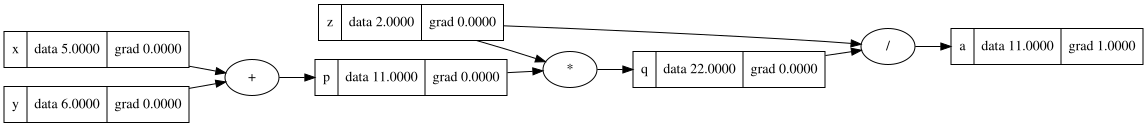

In [118]:
draw_dot(a)

In [117]:
a._backward

<function __main__.neuron.__init__.<locals>.<lambda>()>